<a href="https://colab.research.google.com/github/NU-MSE-LECTURES/465-WINTER2026/blob/main/Week_05/code_examples/example_01_structure_preparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 05 - Example 01: Structure Preparation for TEM/STEM Simulation

This example demonstrates how to prepare atomic structures for TEM/STEM image simulation using the **Atomic Simulation Environment (ASE)** and **abTEM**.

## Topics Covered:
1. Creating basic crystal structures
2. Loading structures from files
3. Building supercells
4. Orienting structures along zone axes
5. Adding thermal motion (Debye-Waller factors)
6. Preparing structures for abTEM simulations
7. Visualization

## Setup and Imports

First, let's import all necessary libraries:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ase import Atoms
from ase.build import bulk, surface, molecule
from ase.visualize.plot import plot_atoms
from ase.io import read, write
import warnings
warnings.filterwarnings('ignore')

# Try importing abTEM (optional for this example)
try:
    from abtem import Potential
    ABTEM_AVAILABLE = True
    print("✓ abTEM is available")
except ImportError:
    ABTEM_AVAILABLE = False
    print("Note: abTEM not available. Some features will be skipped.")

print("✓ All basic libraries imported successfully")

Note: abTEM not available. Some features will be skipped.
✓ All basic libraries imported successfully


---

## 1. Creating Basic Structures

ASE provides convenient functions to create common crystal structures. Let's create a few examples:

In [2]:
# Silicon (diamond cubic structure)
si = bulk('Si', 'diamond', a=5.43)
print(f"Silicon structure:")
print(f"  Lattice parameter: {si.cell.cellpar()[0]:.3f} Å")
print(f"  Number of atoms: {len(si)}")
print(f"  Cell volume: {si.get_volume():.2f} Å³")
print(f"  Chemical formula: {si.get_chemical_formula()}")

Silicon structure:
  Lattice parameter: 3.840 Å
  Number of atoms: 2
  Cell volume: 40.03 Å³
  Chemical formula: Si2


In [3]:
# Gold (FCC structure)
au = bulk('Au', 'fcc', a=4.08)
print(f"Gold structure:")
print(f"  Lattice parameter: {au.cell.cellpar()[0]:.3f} Å")
print(f"  Number of atoms: {len(au)}")
print(f"  Cell volume: {au.get_volume():.2f} Å³")

Gold structure:
  Lattice parameter: 2.885 Å
  Number of atoms: 1
  Cell volume: 16.98 Å³


In [4]:
# Graphene (2D structure)
from ase.build import graphene
graphene_struct = graphene(size=(3, 3, 1), vacuum=10.0)
print(f"Graphene structure:")
print(f"  Lattice parameters: a={graphene_struct.cell.cellpar()[0]:.3f} Å, b={graphene_struct.cell.cellpar()[1]:.3f} Å")
print(f"  Number of atoms: {len(graphene_struct)}")
print(f"  Chemical formula: {graphene_struct.get_chemical_formula()}")

Graphene structure:
  Lattice parameters: a=7.380 Å, b=7.380 Å
  Number of atoms: 18
  Chemical formula: C18


### Visualize the structures

Let's create a simple visualization of our structures:

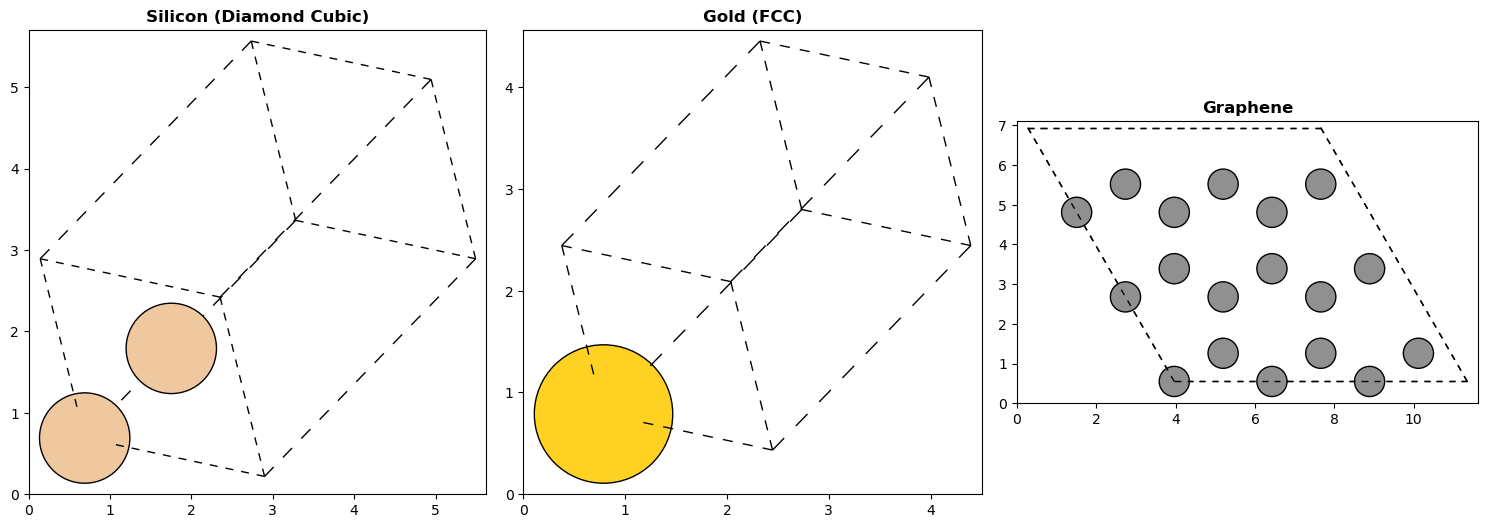

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Silicon
plot_atoms(si, ax=axes[0], radii=0.5, rotation='10x,-10y,0z')
axes[0].set_title('Silicon (Diamond Cubic)', fontsize=12, fontweight='bold')

# Gold
plot_atoms(au, ax=axes[1], radii=0.5, rotation='10x,-10y,0z')
axes[1].set_title('Gold (FCC)', fontsize=12, fontweight='bold')

# Graphene
plot_atoms(graphene_struct, ax=axes[2], radii=0.5, rotation='0x,0y,0z')
axes[2].set_title('Graphene', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

---

## 2. Loading Structures from Files

ASE supports many file formats for importing crystal structures:

- **CIF**: Crystallographic Information File (most common)
- **POSCAR/CONTCAR**: VASP format
- **XYZ**: Simple atomic coordinates
- **PDB**: Protein Data Bank format
- **and many more...**

In [6]:
# Example code for loading structures from files:
print("Example usage:")
print("")
print("# From CIF file")
print("structure = read('structure.cif')")
print("")
print("# From VASP POSCAR")
print("structure = read('POSCAR')")
print("")
print("# From XYZ file")
print("structure = read('coordinates.xyz')")
print("")
print("# ASE auto-detects format from extension")
print("structure = read('structure.ext')")

# You can also save structures in different formats:
# write('silicon.cif', si)
# write('silicon.xyz', si)
# write('POSCAR', si, format='vasp')

Example usage:

# From CIF file
structure = read('structure.cif')

# From VASP POSCAR
structure = read('POSCAR')

# From XYZ file
structure = read('coordinates.xyz')

# ASE auto-detects format from extension
structure = read('structure.ext')


---

## 3. Building Supercells

For TEM/STEM simulations, we often need larger unit cells (supercells) to:
- Reduce periodic boundary artifacts
- Model defects and interfaces
- Match experimental sample thickness

Creating a supercell is very simple in ASE using the multiplication operator:

In [7]:
# Primitive cell
si_prim = bulk('Si', 'diamond', a=5.43)
print(f"Primitive cell:")
print(f"  Atoms: {len(si_prim)}")
print(f"  Cell dimensions: {si_prim.cell.cellpar()[:3]}")
print(f"  Volume: {si_prim.get_volume():.2f} Å³")

Primitive cell:
  Atoms: 2
  Cell dimensions: [3.83958982 3.83958982 3.83958982]
  Volume: 40.03 Å³


In [8]:
# Create 3×3×3 supercell
si_super = si_prim * (3, 3, 3)
print(f"3×3×3 Supercell:")
print(f"  Atoms: {len(si_super)}")
print(f"  Cell dimensions: {si_super.cell.cellpar()[:3]}")
print(f"  Volume: {si_super.get_volume():.2f} Å³")

3×3×3 Supercell:
  Atoms: 54
  Cell dimensions: [11.51876947 11.51876947 11.51876947]
  Volume: 1080.70 Å³


In [9]:
# Create 5×5×1 slab (thin specimen)
si_slab = si_prim * (5, 5, 1)
print(f"5×5×1 Supercell (thin specimen):")
print(f"  Atoms: {len(si_slab)}")
print(f"  Cell dimensions: {si_slab.cell.cellpar()[:3]}")
print(f"  Volume: {si_slab.get_volume():.2f} Å³")

5×5×1 Supercell (thin specimen):
  Atoms: 50
  Cell dimensions: [19.19794911 19.19794911  3.83958982]
  Volume: 1000.64 Å³


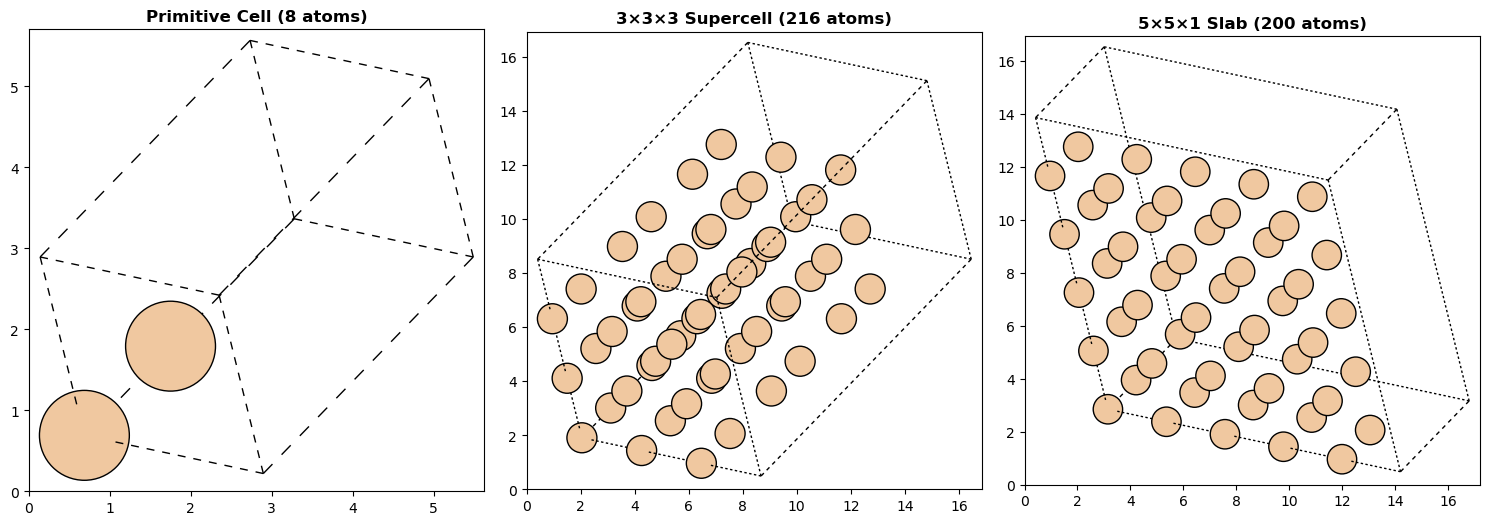

In [10]:
# Visualize primitive vs supercell
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

plot_atoms(si_prim, ax=axes[0], radii=0.5, rotation='10x,-10y,0z')
axes[0].set_title('Primitive Cell (8 atoms)', fontsize=12, fontweight='bold')

plot_atoms(si_super, ax=axes[1], radii=0.5, rotation='10x,-10y,0z')
axes[1].set_title('3×3×3 Supercell (216 atoms)', fontsize=12, fontweight='bold')

plot_atoms(si_slab, ax=axes[2], radii=0.5, rotation='10x,-10y,0z')
axes[2].set_title('5×5×1 Slab (200 atoms)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

---

## 4. Orienting Structures Along Zone Axes

For TEM/STEM imaging, we need to orient the crystal along a specific **zone axis** (viewing direction defined by Miller indices).

Common zone axes for cubic crystals:
- **[001]**: View along the c-axis
- **[110]**: View along face diagonal
- **[111]**: View along body diagonal

In [11]:
from ase.build import cut

def orient_zone_axis(structure, zone_axis):
    """
    Orient a crystal structure along a specific zone axis.
    
    Parameters:
    -----------
    structure : Atoms
        The atomic structure to orient
    zone_axis : tuple
        Miller indices (h, k, l) defining the viewing direction
        
    Returns:
    --------
    Atoms
        Rotated structure with zone axis along z-direction
    """
    if zone_axis == (0, 0, 1):  # [001]
        oriented = structure.copy()
    elif zone_axis == (1, 1, 0):  # [110]
        oriented = cut(structure, a=(1, -1, 0), b=(0, 0, 1), c=(1, 1, 0))
    elif zone_axis == (1, 1, 1):  # [111]
        oriented = cut(structure, a=(1, -1, 0), b=(1, 1, -2), c=(1, 1, 1))
    else:
        h, k, l = zone_axis
        oriented = cut(structure, a=(1, 0, 0), b=(0, 1, 0), c=(h, k, l))
    
    return oriented

In [12]:
# Create structures oriented along different zone axes
si_base = bulk('Si', 'diamond', a=5.43) * (3, 3, 1)

# [001] zone axis
si_001 = orient_zone_axis(si_base, (0, 0, 1))
print(f"Si [001] zone axis:")
print(f"  Cell dimensions: {si_001.cell.cellpar()[:3]}")
print(f"  Number of atoms: {len(si_001)}")

# [110] zone axis
si_110 = orient_zone_axis(si_base, (1, 1, 0))
print(f"\nSi [110] zone axis:")
print(f"  Cell dimensions: {si_110.cell.cellpar()[:3]}")
print(f"  Number of atoms: {len(si_110)}")

Si [001] zone axis:
  Cell dimensions: [11.51876947 11.51876947  3.83958982]
  Number of atoms: 18

Si [110] zone axis:
  Cell dimensions: [11.51876947  3.83958982 19.95109395]
  Number of atoms: 36


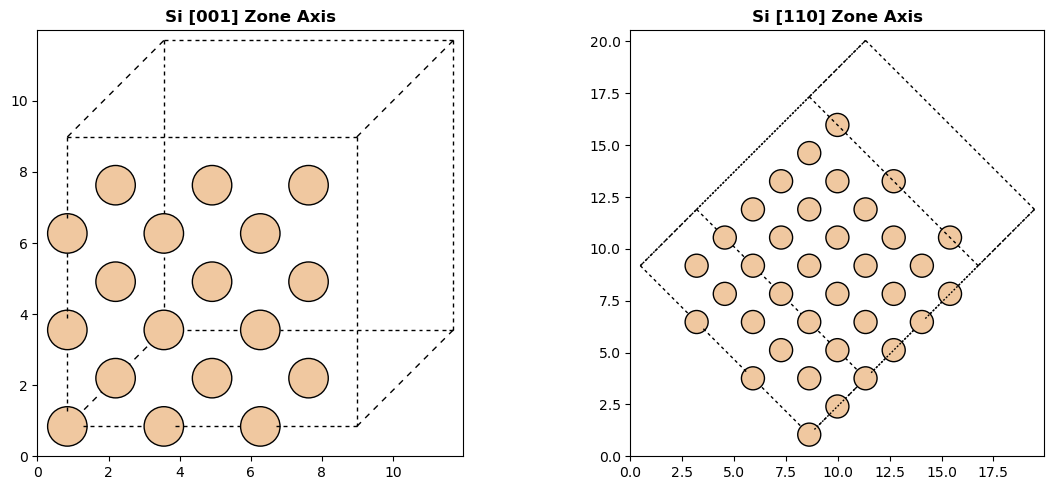

In [13]:
# Visualize different zone axes
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_atoms(si_001, ax=axes[0], radii=0.5, rotation='0x,0y,0z')
axes[0].set_title('Si [001] Zone Axis', fontsize=12, fontweight='bold')

plot_atoms(si_110, ax=axes[1], radii=0.5, rotation='0x,0y,0z')
axes[1].set_title('Si [110] Zone Axis', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

---

## 5. Adding Thermal Motion (Debye-Waller Factors)

Real atoms vibrate around their equilibrium positions due to thermal energy. This affects electron scattering and needs to be included in accurate simulations.

The **Debye-Waller factor** describes the reduction in scattering intensity due to thermal motion:

$$u^2_{\text{rms}} \propto \frac{T}{\theta_D}$$

where:
- $u_{\text{rms}}$ = root-mean-square displacement
- $T$ = temperature (K)
- $\theta_D$ = Debye temperature (material-specific)

In [14]:
def add_thermal_motion(structure, temperature=300, element_params=None):
    """
    Add random thermal displacements to atoms based on Debye-Waller theory.
    
    Parameters:
    -----------
    structure : Atoms
        The atomic structure
    temperature : float
        Temperature in Kelvin
    element_params : dict
        Dictionary of Debye temperatures for each element
        
    Returns:
    --------
    Atoms
        Structure with thermal displacements
    """
    # Default Debye temperatures (K)
    default_debye_temps = {
        'Si': 645,
        'Au': 165,
        'C': 2230,
        'Al': 428,
        'Cu': 343,
        'Fe': 470,
        'Ni': 450,
    }
    
    if element_params is None:
        element_params = default_debye_temps
    
    structure_thermal = structure.copy()
    
    for atom in structure_thermal:
        element = atom.symbol
        
        # Get Debye temperature for this element
        theta_D = element_params.get(element, 300)
        
        # Calculate RMS displacement (empirical formula)
        if temperature > 0:
            u_rms = 0.1 * np.sqrt(temperature / theta_D)
        else:
            u_rms = 0.0
        
        # Add random displacement (Gaussian distribution)
        displacement = np.random.normal(0, u_rms, 3)
        atom.position += displacement
    
    return structure_thermal

In [15]:
# Test thermal motion at different temperatures
si_test = bulk('Si', 'diamond', a=5.43) * (2, 2, 2)

temperatures = [0, 300, 600]
thermal_structures = []

for T in temperatures:
    si_thermal = add_thermal_motion(si_test, temperature=T)
    thermal_structures.append(si_thermal)
    
    # Calculate RMS displacement
    displacements = si_thermal.positions - si_test.positions
    rms = np.sqrt(np.mean(np.sum(displacements**2, axis=1)))
    
    print(f"Temperature: {T:4d} K  →  RMS displacement: {rms:.4f} Å")

Temperature:    0 K  →  RMS displacement: 0.0000 Å
Temperature:  300 K  →  RMS displacement: 0.1210 Å
Temperature:  600 K  →  RMS displacement: 0.1699 Å


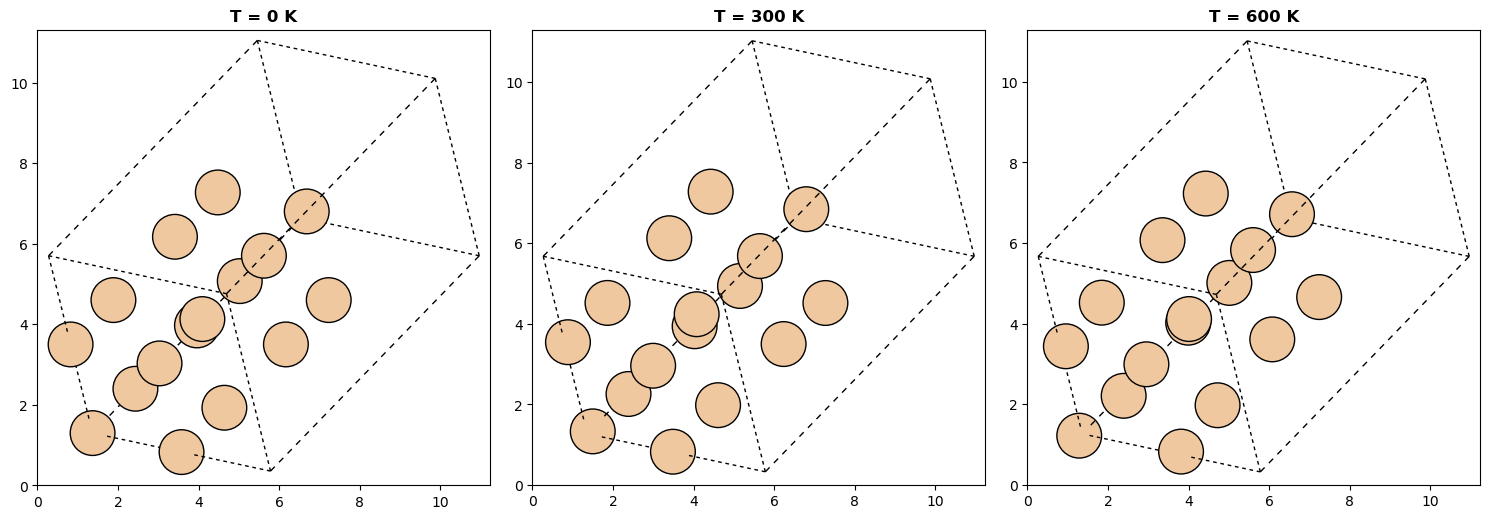

In [16]:
# Visualize effect of thermal motion
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (T, struct) in enumerate(zip(temperatures, thermal_structures)):
    plot_atoms(struct, ax=axes[i], radii=0.5, rotation='10x,-10y,0z')
    axes[i].set_title(f'T = {T} K', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

---

## 6. Preparing for abTEM Simulations

**abTEM** (ab initio TEM) is a Python package for simulating TEM/STEM images using the multislice algorithm.

The key object is the `Potential`, which represents the electrostatic potential of the atomic structure sliced along the beam direction.

In [17]:
if ABTEM_AVAILABLE:
    # Create a structure for simulation
    si_sim = bulk('Si', 'diamond', a=5.43) * (3, 3, 3)
    
    print(f"Structure properties:")
    print(f"  Number of atoms: {len(si_sim)}")
    print(f"  Cell dimensions: {si_sim.cell.cellpar()[:3]}")
    print(f"  Thickness (z): {si_sim.cell[2, 2]:.2f} Å")
    
    # Create potential object
    sampling = 0.05  # Å/pixel
    slice_thickness = 2.0  # Å
    
    potential = Potential(
        si_sim,
        sampling=sampling,
        slice_thickness=slice_thickness,
        parametrization='lobato'  # Accurate scattering parameters
    )
    
    print(f"\nPotential created:")
    print(f"  Sampling: {sampling} Å/pixel")
    print(f"  Slice thickness: {slice_thickness} Å")
    print(f"  Grid shape: {potential.extent}")
    print(f"  Number of slices: {len(potential)}")
else:
    print("abTEM not available - skipping this section")
    potential = None

abTEM not available - skipping this section


### Visualize Potential Slices

In [18]:
if potential is not None:
    # Select 5 slices evenly distributed through the sample
    num_slices = 5
    slice_indices = np.linspace(0, len(potential)-1, num_slices, dtype=int)
    
    fig, axes = plt.subplots(1, num_slices, figsize=(15, 3))
    
    for i, idx in enumerate(slice_indices):
        pot_slice = potential[idx].compute()
        im = axes[i].imshow(pot_slice.array, cmap='viridis')
        axes[i].set_title(f'Slice {idx}', fontsize=10)
        axes[i].axis('off')
    
    plt.colorbar(im, ax=axes, orientation='horizontal', pad=0.05, label='Potential (V·Å)')
    plt.tight_layout()
    plt.show()
else:
    print("Potential visualization requires abTEM")

Potential visualization requires abTEM


---

## 7. Summary Visualization

Let's create a comprehensive figure showing all the different structures we've prepared:

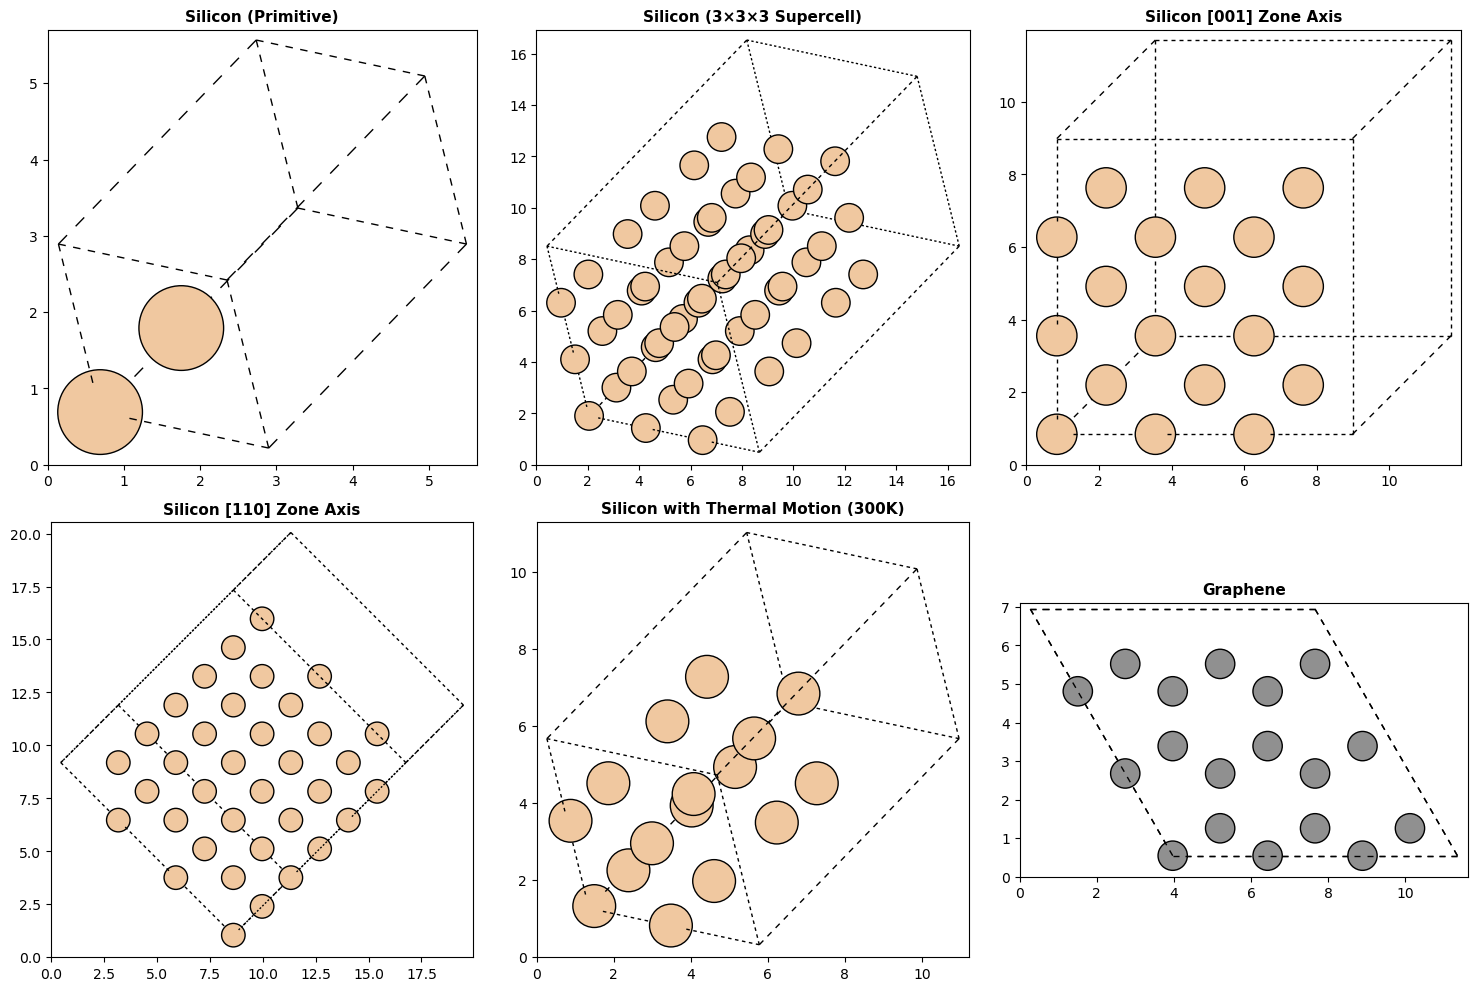

✓ Summary visualization saved as 'structure_preparation_summary.png'


In [19]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Row 1: Different materials
plot_atoms(si, ax=axes[0, 0], radii=0.5, rotation='10x,-10y,0z')
axes[0, 0].set_title('Silicon (Primitive)', fontsize=11, fontweight='bold')

plot_atoms(si_super, ax=axes[0, 1], radii=0.5, rotation='10x,-10y,0z')
axes[0, 1].set_title('Silicon (3×3×3 Supercell)', fontsize=11, fontweight='bold')

plot_atoms(si_001, ax=axes[0, 2], radii=0.5, rotation='0x,0y,0z')
axes[0, 2].set_title('Silicon [001] Zone Axis', fontsize=11, fontweight='bold')

# Row 2: Zone axes and thermal motion
plot_atoms(si_110, ax=axes[1, 0], radii=0.5, rotation='0x,0y,0z')
axes[1, 0].set_title('Silicon [110] Zone Axis', fontsize=11, fontweight='bold')

plot_atoms(thermal_structures[1], ax=axes[1, 1], radii=0.5, rotation='10x,-10y,0z')
axes[1, 1].set_title('Silicon with Thermal Motion (300K)', fontsize=11, fontweight='bold')

plot_atoms(graphene_struct, ax=axes[1, 2], radii=0.5, rotation='0x,0y,0z')
axes[1, 2].set_title('Graphene', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('structure_preparation_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Summary visualization saved as 'structure_preparation_summary.png'")

---

## Key Takeaways

✓ **ASE** provides powerful tools for creating and manipulating crystal structures  
✓ Use **supercells** to create realistic sample sizes for simulation  
✓ Orient structures along specific **zone axes** for desired imaging conditions  
✓ Include **thermal motion** for accurate simulation results  
✓ Prepare structures as **Potential** objects for abTEM multislice simulations  